Usando playwright para extraccion y la carga

In [18]:
from playwright.async_api import async_playwright
from pymongo import MongoClient, UpdateOne
import datetime
import random 

# --- 1. CONEXIÓN A NOSQL ---
cliente = MongoClient('mongodb://localhost:27017/')
# Creamos una colección limpia para esta extracción masiva
coleccion = cliente['mercado_inmobiliario']['departamentos_masivo']

# Diccionario con 15 zonas clave de la CDMX
colonias_objetivo = {
    "Condesa": "condesa",
    "Roma Norte": "roma-norte",
    "Roma Sur": "roma-sur",
    "Doctores": "doctores", 
    "Del Valle": "del-valle",
    "Narvarte": "narvarte",
    "Polanco": "polanco",
    "Coyoacán": "coyoacan",
    "Santa Fe": "santa-fe",
    "Lomas de Chapultepec": "lomas-de-chapultepec",
    "San Rafael": "san-rafael",
    "Santa María la Ribera": "santa-maria-la-ribera",
    "Centro": "centro",
    "Escandón": "escandon",
    "Portales": "portales"
}

print("🚀 Iniciando motor de extracción masiva...")
playwright = await async_playwright().start()

browser = await playwright.chromium.launch(
    headless=False,
    args=["--disable-blink-features=AutomationControlled"], 
    ignore_default_args=["--enable-automation"] 
)

contexto = await browser.new_context(
    user_agent="Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    viewport={"width": 1366, "height": 768}
)

page = await contexto.new_page()
await page.add_init_script("Object.defineProperty(navigator, 'webdriver', {get: () => undefined})")

# --- 2. BUCLE MULTI-PÁGINA ---
for nombre_colonia, slug in colonias_objetivo.items():
    
    # Exploramos las primeras 3 páginas de cada colonia
    for pagina in range(1, 4):
        
        # Lógica dinámica de URL para paginación
        if pagina == 1:
            url = f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}.html"
        else:
            url = f"https://www.inmuebles24.com/departamentos-en-renta-en-{slug}-pagina-{pagina}.html"
            
        print("\n" + "="*50)
        print(f"📍 {nombre_colonia} | 📄 Página {pagina}")
        
        try:
            await page.goto(url)
            
            tiempo_pausa = random.randint(15000, 22000) 
            print(f"⏳ Pausa táctica de {tiempo_pausa / 1000}s...")
            await page.wait_for_timeout(tiempo_pausa)
            
            # Hacemos scroll múltiple para forzar a que carguen todos los anuncios ocultos
            print("🖱️ Escaneando la página completa...")
            for _ in range(3):
                await page.mouse.wheel(0, 1500)
                await page.wait_for_timeout(1500)
            
            tarjetas = await page.locator("div[class*='postingCard'], div[class*='PostingCard']").all()
            registros_extraidos = []
            
            # Quitamos el límite: ahora procesa TODAS las tarjetas que existan en la página
            for tarjeta in tarjetas: 
                try:
                    precio_locator = tarjeta.locator("div[class*='postingPrices-module__price-container']")
                    precio_raw = await precio_locator.first.inner_text() if await precio_locator.count() > 0 else "Sin precio"
                    
                    h2_elementos = await tarjeta.locator("h2").all()
                    titulo_raw = "Sin título"
                    
                    for h2 in h2_elementos:
                        texto = await h2.inner_text()
                        if "MN" not in texto:
                            titulo_raw = texto
                            break
                    
                    documento = {
                        "titulo": titulo_raw.strip()[:100] + "...", 
                        "precio_raw": precio_raw.strip(),
                        "colonia": nombre_colonia, 
                        "fecha_extraccion": datetime.datetime.now().strftime("%Y-%m-%d")
                    }
                    
                    if documento["precio_raw"] != "Sin precio" and documento["titulo"] != "Sin título":
                        registros_extraidos.append(documento)
                        
                except Exception as e:
                    continue

            print(f"✅ Se capturaron {len(registros_extraidos)} registros.")

            # --- 3. INGESTA NOSQL ---
            if registros_extraidos:
                operaciones_db = []
                for reg in registros_extraidos:
                    operaciones_db.append(UpdateOne(
                        {"titulo": reg["titulo"], "colonia": reg["colonia"]}, 
                        {"$set": reg}, 
                        upsert=True    
                    ))
                    
                resultado = coleccion.bulk_write(operaciones_db)
                print(f"💾 Upserts reales inyectados: {resultado.upserted_count + resultado.modified_count}")
                
        except Exception as e:
            print(f"❌ Error al procesar {nombre_colonia} página {pagina}: {e}")

# --- 4. CIERRE DE SESIÓN ---
print("\n" + "="*50)
print(f"📊 Total masivo en MongoDB ('departamentos_masivo'): {coleccion.count_documents({})}")
await browser.close()
await playwright.stop()
print("🏁 Recolección profunda finalizada.")

🚀 Iniciando motor de extracción masiva...

📍 Condesa | 📄 Página 1
⏳ Pausa táctica de 19.181s...
🖱️ Escaneando la página completa...
✅ Se capturaron 180 registros.
💾 Upserts reales inyectados: 60

📍 Condesa | 📄 Página 2
⏳ Pausa táctica de 18.165s...
🖱️ Escaneando la página completa...
✅ Se capturaron 180 registros.
💾 Upserts reales inyectados: 57

📍 Condesa | 📄 Página 3
⏳ Pausa táctica de 20.371s...
🖱️ Escaneando la página completa...
✅ Se capturaron 180 registros.
💾 Upserts reales inyectados: 47

📍 Roma Norte | 📄 Página 1
⏳ Pausa táctica de 18.593s...
🖱️ Escaneando la página completa...
✅ Se capturaron 180 registros.
💾 Upserts reales inyectados: 59

📍 Roma Norte | 📄 Página 2
⏳ Pausa táctica de 15.334s...
🖱️ Escaneando la página completa...
✅ Se capturaron 180 registros.
💾 Upserts reales inyectados: 29

📍 Roma Norte | 📄 Página 3
⏳ Pausa táctica de 21.144s...
🖱️ Escaneando la página completa...
✅ Se capturaron 180 registros.
💾 Upserts reales inyectados: 29

📍 Roma Sur | 📄 Página 1
⏳ Paus

Tranformacion de datos usando pandas

In [7]:
import pandas as pd
from pymongo import MongoClient

print(' Conectando a MongoDB y extrayendo datos para DataFrame...')
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_cdmx']

# 1. Extraemos todo y lo convertimos en una lista de diccionarios
datos_crudos = list(coleccion.find())

# 2. Inyectamos la lista directamente en un DataFrame de Pandas
df = pd.DataFrame(datos_crudos)

# Eliminamos la columna '_id' interna de Mongo porque no la necesitamos para análisis
if '_id' in df.columns:
    df = df.drop(columns=['_id'])

print('DataFrame original (sucio)')
display(df.head()) # 'display' renderiza una tabla bonita en Jupyterdisplay' renderiza una tabla bonita en Jupyter

print("\n Limpiando y normalizando columnas...")

# 3. Limpieza de la columna de precio
# Reemplazamos "MN", espacios en blanco y comas por nada ("")
df['precio_numerico'] = df['precio_raw'].str.replace('MN', '', regex=False)
df['precio_numerico'] = df['precio_numerico'].str.replace(',', '', regex=False)
df['precio_numerico'] = df['precio_numerico'].str.strip()

# 4. Cast (Conversión) de texto a número flotante
# errors='coerce' forzará a NaN (Not a Number) cualquier cosa que no se pueda convertir
df['precio_numerico'] = pd.to_numeric(df['precio_numerico'], errors='coerce')

print('DataFrame limpio y listo para matematicas:')
display(df[['titulo', 'colonia', 'precio_numerico']].head())

# Validamos los tipos de datos para confirmar que 'precio_numerico' ya es float64
print("\n Tipos de datos actuales:")
print(df.dtypes)




Future exception was never retrieved
future: <Future finished exception=Exception('Connection closed while reading from the driver')>
Exception: Connection closed while reading from the driver


 Conectando a MongoDB y extrayendo datos para DataFrame...
DataFrame original (sucio)


,colonia,titulo,fecha_extraccion,precio_raw
0,Condesa,Renta de departamentos nuevos en Insurgentes R...,2026-09-30,"MN 25,150"
1,Condesa,Sin título...,2026-10-01,"MN 27,500"
2,Condesa,"Con una ubicación privilegiada, cerca de resta...",2026-10-01,"MN 39,500"
3,Condesa,¡Bienvenido al paraíso urbano en el corazón de...,2026-10-01,"MN 27,500"
4,Condesa,Residencia con jardín Y roof top - se entrega ...,2026-10-01,"MN 67,000"



 Limpiando y normalizando columnas...
DataFrame limpio y listo para matematicas:


,titulo,colonia,precio_numerico
0,Renta de departamentos nuevos en Insurgentes R...,Condesa,25150.0
1,Sin título...,Condesa,27500.0
2,"Con una ubicación privilegiada, cerca de resta...",Condesa,39500.0
3,¡Bienvenido al paraíso urbano en el corazón de...,Condesa,27500.0
4,Residencia con jardín Y roof top - se entrega ...,Condesa,67000.0



 Tipos de datos actuales:
colonia                 str
titulo                  str
fecha_extraccion        str
precio_raw              str
precio_numerico     float64
dtype: object


In [8]:
import pandas as pd
from pymongo import MongoClient

# 1. Extracción rápida de MongoDB
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_cdmx']
df = pd.DataFrame(list(coleccion.find()))

# 2. Conteo agrupado por colonia
print("🏢 Departamentos únicos reales en tu base de datos:\n")
conteo_colonias = df['colonia'].value_counts().reset_index()
conteo_colonias.columns = ['Colonia', 'Total_Anuncios_Unicos']

display(conteo_colonias)

🏢 Departamentos únicos reales en tu base de datos:



,Colonia,Total_Anuncios_Unicos
0,Condesa,5
1,Roma Norte,3
2,Doctores,3
3,Del Valle,3
4,Narvarte,3
5,Polanco,3
6,Coyoacán,3


🗺️ Preparando el motor geoespacial...
📥 Descargando polígonos oficiales de la CDMX (esto puede tomar unos segundos)...
✅ Descarga completada.
🧠 Extrayendo coordenadas geométricas a la memoria...
🎨 Renderizando lienzo cartográfico de la CDMX:


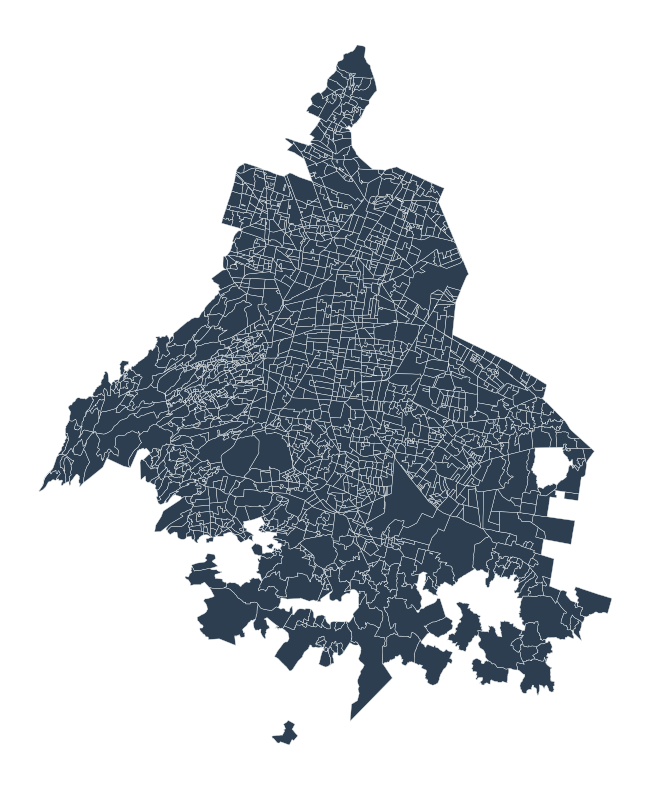


📊 Explorando las entrañas del GeoDataFrame:


,ENT,CVEDT,NOMDT,DTTOLOC,CVEUT,NOMUT,ID,geometry
0,9,2,AZCAPOTZALCO,05,02-001,AGUILERA,1,"POLYGON ((-99.15901 19.47374, -99.15882 19.473..."
1,9,2,AZCAPOTZALCO,05,02-002,ALDANA,2,"POLYGON ((-99.14858 19.47156, -99.14863 19.471..."
2,9,2,AZCAPOTZALCO,05,02-005,ANGEL ZIMBRON,3,"POLYGON ((-99.19044 19.47144, -99.19031 19.471..."


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import urllib.request

print("🗺️ Preparando el motor geoespacial...")

# Archivo de destino local
archivo_geojson = "colonias_cdmx.geojson"
# La liga directa y oficial que obtuviste del portal de la CDMX
url_mapa = "https://datos.cdmx.gob.mx/dataset/04a1900a-0c2f-41ed-94dc-3d2d5bad4065/resource/8070ee81-9111-437e-a3dd-0c3cc6dce9f4/download/8070ee81-9111-437e-a3dd-0c3cc6dce9f4.json"

# Automatizamos la descarga directa al disco duro
if not os.path.exists(archivo_geojson):
    print("📥 Descargando polígonos oficiales de la CDMX (esto puede tomar unos segundos)...")
    urllib.request.urlretrieve(url_mapa, archivo_geojson)
    print("✅ Descarga completada.")
else:
    print("✅ El mapa base ya está guardado en tu carpeta local.")

print("🧠 Extrayendo coordenadas geométricas a la memoria...")
mapa_cdmx = gpd.read_file(archivo_geojson)

print("🎨 Renderizando lienzo cartográfico de la CDMX:")
fig, ax = plt.subplots(figsize=(10, 10))
mapa_cdmx.plot(ax=ax, color='#2C3E50', edgecolor='#ECF0F1', linewidth=0.3)
ax.axis('off') # Apagamos el marco del plano cartesiano
plt.show()

print("\n📊 Explorando las entrañas del GeoDataFrame:")
display(mapa_cdmx.head(3))

🔌 Conectando a la nueva bóveda masiva de MongoDB...
🧠 Cruzando 705 registros con los polígonos del gobierno...
  ✅ CENTRO: Asignado a 16 subdivisiones.
  ✅ CONDESA: Asignado a 2 subdivisiones.
  ✅ COYOACAN: Asignado a 9 subdivisiones.
  ✅ DEL VALLE: Asignado a 10 subdivisiones.
  ✅ DOCTORES: Asignado a 5 subdivisiones.
  ✅ ESCANDON: Asignado a 2 subdivisiones.
  ✅ LOMAS DE CHAPULTEPEC: Asignado a 6 subdivisiones.
  ✅ POLANCO: Asignado a 9 subdivisiones.
  ✅ ROMA NORTE: Asignado a 3 subdivisiones.
  ✅ ROMA SUR: Asignado a 2 subdivisiones.
  ✅ SANTA FE: Asignado a 6 subdivisiones.
  ✅ SANTA MARIA LA RIBERA: Asignado a 3 subdivisiones.

🎨 Renderizando el mapa con la nueva densidad de datos...


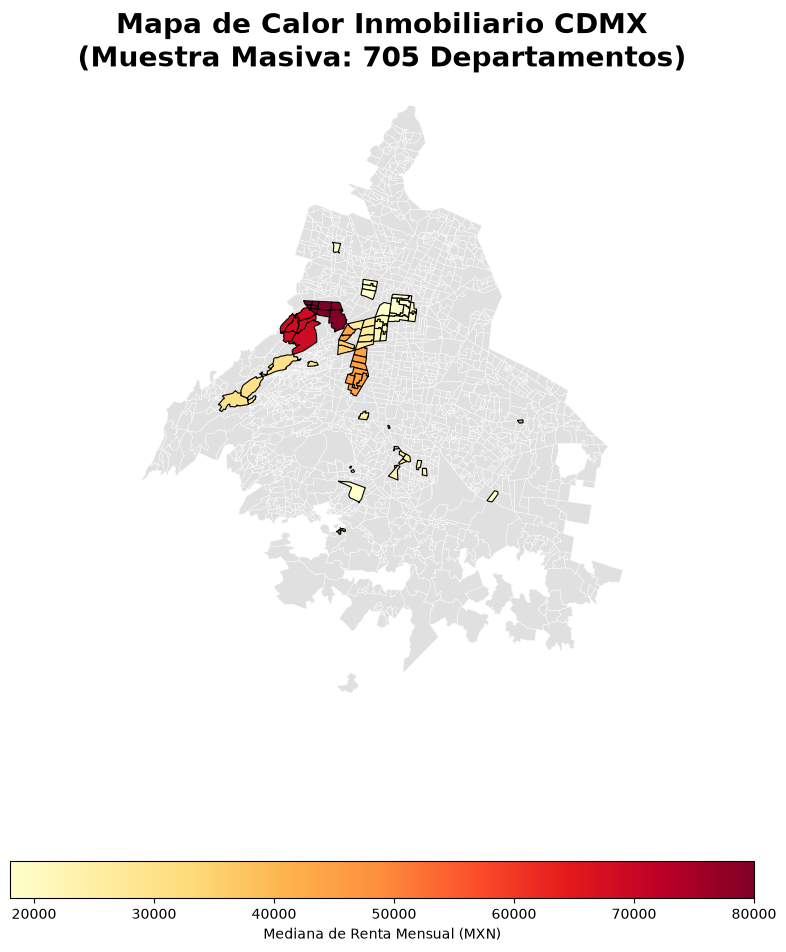

In [21]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pymongo import MongoClient
import unicodedata

print("🔌 Conectando a la nueva bóveda masiva de MongoDB...")

# 1. Extracción apuntando a la NUEVA colección
cliente = MongoClient('mongodb://localhost:27017/')
coleccion = cliente['mercado_inmobiliario']['departamentos_masivo']
df = pd.DataFrame(list(coleccion.find()))

# Limpieza y conversión a números
df['precio_numerico'] = df['precio_raw'].str.replace('MN', '', regex=False)
df['precio_numerico'] = df['precio_numerico'].str.replace(',', '', regex=False).str.strip()
df['precio_numerico'] = pd.to_numeric(df['precio_numerico'], errors='coerce')

# 2. Agrupación Estadística (Mediana)
df_estadisticas = df.groupby('colonia')['precio_numerico'].median().reset_index()

def normalizar_texto(texto):
    if pd.isna(texto): return ""
    texto = str(texto).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

df_estadisticas['llave_cruce'] = df_estadisticas['colonia'].apply(normalizar_texto)

print(f"🧠 Cruzando {len(df)} registros con los polígonos del gobierno...")

# 3. Preparamos el mapa oficial
mapa_cdmx = gpd.read_file("colonias_cdmx.geojson")
mapa_cdmx['llave_oficial'] = mapa_cdmx['NOMUT'].apply(normalizar_texto)
mapa_cdmx['precio_asignado'] = pd.NA

# 4. El Cruce Inteligente (Substring Mapping)
colonias_encontradas = 0
for index, row in df_estadisticas.iterrows():
    zona_extraida = row['llave_cruce']
    precio_mediano = row['precio_numerico']
    
    mascara = mapa_cdmx['llave_oficial'].str.contains(zona_extraida, na=False)
    
    if mascara.any():
        mapa_cdmx.loc[mascara, 'precio_asignado'] = precio_mediano
        colonias_encontradas += 1
        print(f"  ✅ {zona_extraida}: Asignado a {mascara.sum()} subdivisiones.")

print(f"\n🎨 Renderizando el mapa con la nueva densidad de datos...")

# 5. Visualización
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
mapa_cdmx.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.3)

# Hacemos una copia limpia de los datos que sí cruzaron
zonas_calientes = mapa_cdmx.dropna(subset=['precio_asignado']).copy()

# ⬅️ EL PARCHE: Forzamos matemáticamente la columna a formato numérico (float64)
zonas_calientes['precio_asignado'] = pd.to_numeric(zonas_calientes['precio_asignado'])

# Ahora GeoPandas detectará que son números y creará una barra de color (colorbar) correctamente
zonas_calientes.plot(
    column='precio_asignado', 
    cmap='YlOrRd', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='black', 
    legend=True,
    legend_kwds={'label': "Mediana de Renta Mensual (MXN)", 'orientation': "horizontal", 'shrink': 0.6}
)

ax.set_title('Mapa de Calor Inmobiliario CDMX\n(Muestra Masiva: 705 Departamentos)', fontdict={'fontsize': 20, 'fontweight': 'bold'})
ax.axis('off')
plt.show()

In [25]:
import folium
import mapclassify

print("🌐 Construyendo el mapa interactivo web...")

# 1. Proyección Cartográfica: Aseguramos que el mapa use coordenadas GPS estándar (WGS84)
zonas_calientes = zonas_calientes.to_crs(epsg=4326)

# 2. Ingeniería de Características (Feature Engineering) visual
# Creamos una columna limpia exclusiva para el cuadro de texto (ej. "$ 25,000 MXN")
zonas_calientes['Renta_Mensual'] = zonas_calientes['precio_asignado'].apply(lambda x: f"${x:,.0f} MXN")

# 3. Renderizado Interactivo (Folium Engine con Servidores Esri)
mapa_interactivo = zonas_calientes.explore(
    column="precio_asignado", 
    tooltip=["NOMUT", "Renta_Mensual"], 
    tooltip_kwds={"aliases": ["Colonia:", "Renta Mediana:"]}, 
    cmap="YlOrRd", 
    # ⬅️ EL PARCHE: Conectamos directo al servidor empresarial de Esri
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ", # Requisito legal de atribución
    legend_kwds={"caption": "Mediana de Renta Mensual (MXN)"},
    style_kwds={"color": "black", "weight": 1, "fillOpacity": 0.8} 
)

# 4. Exportación
archivo_salida = "mapa_inmobiliario_cdmx.html"
mapa_interactivo.save(archivo_salida)
print(f"✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como '{archivo_salida}'.")

# 5. Desplegamos el mapa
mapa_interactivo

🌐 Construyendo el mapa interactivo web...
✅ ¡Éxito! Tu mapa web 100% interactivo se guardó como 'mapa_inmobiliario_cdmx.html'.
